## Selezionare particelle del Modello Standard con particolari proprietà

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as img
import pandas as pd

Impariamo qui il concetto di **import** ovvero richiamare funzionalità da altri programmi o pacchetti Python:
* [Importazione in Python](04_14.ipynb)

In [17]:
particles = {'electron','muon','tau','nu_e','nu_mu','nu_tau',
             'uquark','dquark','squark','cquark','bquark','tquark',
             'wboson','zboson','gluon','photon','higgs'} 

myimages = {}
for particle in particles:
    myimages[particle] = './sm_particles/'+particle+'.jpg'    

for part, imag in myimages.items() :
    print (f'{part:>10},', imag)

     nu_mu, ./sm_particles/nu_mu.jpg
     gluon, ./sm_particles/gluon.jpg
    uquark, ./sm_particles/uquark.jpg
       tau, ./sm_particles/tau.jpg
    wboson, ./sm_particles/wboson.jpg
    tquark, ./sm_particles/tquark.jpg
    zboson, ./sm_particles/zboson.jpg
    squark, ./sm_particles/squark.jpg
  electron, ./sm_particles/electron.jpg
    dquark, ./sm_particles/dquark.jpg
    bquark, ./sm_particles/bquark.jpg
      nu_e, ./sm_particles/nu_e.jpg
    nu_tau, ./sm_particles/nu_tau.jpg
     higgs, ./sm_particles/higgs.jpg
    photon, ./sm_particles/photon.jpg
      muon, ./sm_particles/muon.jpg
    cquark, ./sm_particles/cquark.jpg


In questa parte di codice vediamo un altro esempio di **collezione** molto usata in Python:
* [Gli insiemi (set)](06_03.00.ipynb)

In [3]:
particle_data = {    # charge, spin, generation, type
    'electron' : ['-1','1/2','1','l'],
    'muon' : ['-1','1/2','2','l'],
    'tau' : ['-1','1/2','3','l'],
    'nu_e' : ['0','1/2','1','l'],
    'nu_mu' : ['0','1/2','2','l'],
    'nu_tau' : ['0','1/2','3','l'],
    'uquark' : ['2/3','1/2','1','q'],
    'cquark' : ['2/3','1/2','2','q'],
    'tquark' : ['2/3','1/2','3','q'],
    'dquark' : ['-1/3','1/2','1','q'],
    'squark' : ['-1/3','1/2','2','q'],
    'bquark' : ['-1/3','1/2','3','q'],
    'photon' : ['0','1','0','wb'],
    'gluon' :  ['0','1','0','sb'],
    'wboson' : ['1','1','0','wb'],
    'zboson' : ['0','1','0','wb'],
    'higgs' : ['0','0','0','hb']
}

pdata = pd.DataFrame(particle_data, index = ['charge','spin','generation','type'])
print (pdata)

           electron muon  tau nu_e nu_mu nu_tau uquark cquark tquark dquark  \
charge           -1   -1   -1    0     0      0    2/3    2/3    2/3   -1/3   
spin            1/2  1/2  1/2  1/2   1/2    1/2    1/2    1/2    1/2    1/2   
generation        1    2    3    1     2      3      1      2      3      1   
type              l    l    l    l     l      l      q      q      q      q   

           squark bquark photon gluon wboson zboson higgs  
charge       -1/3   -1/3      0     0      1      0     0  
spin          1/2    1/2      1     1      1      1     0  
generation      2      3      0     0      0      0     0  
type            q      q     wb    sb     wb     wb    hb  


Qui invece vediamo come trasformare un dizionario - i cui valori sono in realtà **liste** di valori - in  **tabelle a due dimensioni**:
* [Le strutture dati pandas (Pandas DataFrames)](07_14.02.ipynb)

In [18]:
myimages_short = {part_name : './sm_particles/'+part_name+'.jpg' for part_name in particle_data.keys()}

for part, imag in myimages_short.items() :
    print (f'{part:>10},', imag)

  electron, ./sm_particles/electron.jpg
      muon, ./sm_particles/muon.jpg
       tau, ./sm_particles/tau.jpg
      nu_e, ./sm_particles/nu_e.jpg
     nu_mu, ./sm_particles/nu_mu.jpg
    nu_tau, ./sm_particles/nu_tau.jpg
    uquark, ./sm_particles/uquark.jpg
    cquark, ./sm_particles/cquark.jpg
    tquark, ./sm_particles/tquark.jpg
    dquark, ./sm_particles/dquark.jpg
    squark, ./sm_particles/squark.jpg
    bquark, ./sm_particles/bquark.jpg
    photon, ./sm_particles/photon.jpg
     gluon, ./sm_particles/gluon.jpg
    wboson, ./sm_particles/wboson.jpg
    zboson, ./sm_particles/zboson.jpg
     higgs, ./sm_particles/higgs.jpg


* `myimages_short` contiene esattamente gli stessi dati di `myimages` ma è stato creato a partire dal dizionario con le proprietà delle particelle **in un'unica istruzione**.
* Questo è un esempio di **autodefinizione (comprehension)** in Python e può essere usata per creare molte collezioni diverse.
* [Autodefinizione di dizionari](06_02.ipynb)  

In [19]:
pdata = pdata.transpose()
print (pdata)

         charge spin generation type
electron     -1  1/2          1    l
muon         -1  1/2          2    l
tau          -1  1/2          3    l
nu_e          0  1/2          1    l
nu_mu         0  1/2          2    l
nu_tau        0  1/2          3    l
uquark      2/3  1/2          1    q
cquark      2/3  1/2          2    q
tquark      2/3  1/2          3    q
dquark     -1/3  1/2          1    q
squark     -1/3  1/2          2    q
bquark     -1/3  1/2          3    q
photon        0    1          0   wb
gluon         0    1          0   sb
wboson        1    1          0   wb
zboson        0    1          0   wb
higgs         0    0          0   hb


In [21]:
sel = 'charge'
selval = '1/3'

if (sel == 'charge') :
    possible_selvals = [selval, '-' + selval, selval[1:]]
elif (sel == 'type' and selval == 'b') :
    possible_selvals = ['wb','sb','hb']
else:
    possible_selvals = [selval]
    
sel_pdata = pdata[ pdata[sel].isin(possible_selvals) ] 
print (sel_pdata)

       charge spin generation type
dquark   -1/3  1/2          1    q
squark   -1/3  1/2          2    q
bquark   -1/3  1/2          3    q


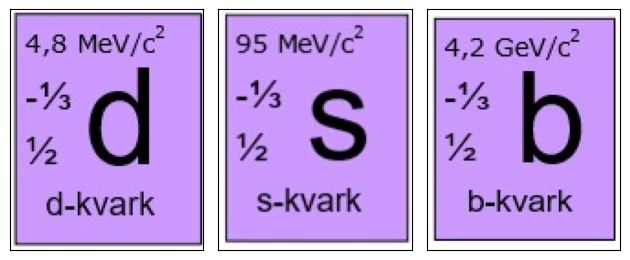

In [22]:
figure, axes_list = plt.subplots(ncols=3,nrows=(len(sel_pdata.index) + 2) // 3)

for axes in axes_list.ravel():
    axes.get_xaxis().set_visible(False)
    axes.get_yaxis().set_visible(False)

for axes, selparticle in zip(axes_list.ravel(), range(len(sel_pdata.index)) ): 
    image_name = myimages[ sel_pdata.index[selparticle] ]
    image = img.imread(image_name)
    axes.imshow(image)

figure.tight_layout()

In [23]:
plt.show()

Quando si usa un **pacchetto esterno** come _matplotlib_ la documentazione non si trova in generale su manuali di Python. Va cercata la relativa guida dell'utente, ad es.:
* [Guida utente matplotlib](https://matplotlib.org/stable/users/index)

In questo caso vediamo:
* `subplots` produce una tupla il cui primo oggetto è una figura che verrà mostrata a schermo e il secondo è una lista di grafici (chiamati `axes` in _matplotlib_, molto fuorviante), disposti nella figura in uno schema _nrows x ncols_. 
* `get_xaxis()` e `get_yaxis()` accedono agli assi dei grafici e in questo caso li rendono non visibili perché vogliamo mostrare immagini e non grafici.
* `imread` e `imshow` caricano e mostrano delle immagini, rispettivamente
* `tight_layout` dispone correttamente i grafici nel subplot e infine `show` mostra il risultato complessivo.

Vi sono inoltre due funzioni interessanti di Python:
* `ravel` (appianare, attributo di una `list`) : trasforma una lista di _nrows_ liste, ciascuna di _ncols_ elementi, in un'unica lista di _nrow x ncol_ elementi.
* `zip` (operatore con **due** iterabili come argomenti): itera simultaneamente incrementando i due, il ciclo si ferma quando il primo dei due finisce i suoi elementi.